# Análise dos Microdados do ENEM 2024

Este notebook apresenta algumas análises exploratórias com os microdados do ENEM 2024, utilizando Python, Pandas e Matplotlib.

As análises incluem:

- visualização inicial dos dados
- filtro de candidatos aptos ao SiSU por município
- médias das notas por unidade federativa
- criação de uma média simples geral
- ranking das unidades federativas
- gráfico da quantidade de participantes por UF

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Configuração de exibição

Nesta etapa, configuramos o Pandas para exibir todas as colunas e linhas quando necessário.

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

## Leitura dos dados

Leitura do arquivo de resultados do ENEM 2024 e tratamento dos dados faltantes.

In [3]:
df = pd.read_csv("RESULTADOS_2024.csv", sep=";", encoding="latin1")
df = df.dropna(subset=["NU_NOTA_REDACAO", "NU_NOTA_MT", "NU_NOTA_LC", "NU_NOTA_CN", "NU_NOTA_CH"])

## Visualização inicial dos dados

In [4]:
df.head()

,NU_SEQUENCIAL,NU_ANO,CO_ESCOLA,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
0,206403,2024,23052929.0,2301406.0,Aratuba,23.0,CE,2.0,1.0,1.0,2301406,Aratuba,23,CE,1,1,1,1,1420.0,1383.0,1395.0,1408.0,436.8,377.8,423.4,427.1,CAABADDBBBACACACDEABDBABDDCCBACDCCBAACCABCBAC,BEABBCDABCDBAEEBDDABCCDAADDABACDDAB..........,BCADBCDCEDBDDBDDCDBCBB*BBDEAEEBCDCABBDDAAECEE,CBDCCADBBECCBADEACCBDCACECDDABBDBADBAAEDBCCAB,1,CAEDAACCAEEXCBBAEDBBCAACDEDCBCEECAAEDDDEBBDDB,CECEBEBCDBADDEBBABCDCAECEDADBAEABEADCEDADACBC,CAAAECDDDAECBECEDDCBDEDDCECBDCBCEADBBDBDDCBEDA...,CECEBEDADCAADECDBBCEBDCCCACABBABBADDDCEADBBCE,1.0,80.0,60.0,60.0,80.0,20.0,300.0
1,3604651,2024,42103770.0,4218004.0,Tijucas,42.0,SC,4.0,1.0,1.0,4218004,Tijucas,42,SC,1,1,1,1,1422.0,1384.0,1396.0,1410.0,521.9,601.9,605.5,689.2,EBDEEADAECCAAEDBBEDABACDBCEEDDDEDBDDABDBCCECA,BADBACDAECEDEABBEADDBBDEBEDADEDEEACBBECABCEDA,AACEACADECBCDAEEBEDCBCBEDDCDEAEDEBDABDCECDDDB,DBAEDBECBDDBCCBBABBDECCCCEECBACCDBCDAAABBAAAD,0,BBCEDBBAEXCCAEDDBCAEDAACAAEDDDEBBECBCEEDCAACD,DADABCDCECEDEBBBEBCDBADACBCADCEBEADBAECAECEDA,AACEADDDACDADECBBDBEEBDDECCBEDDCADBBDEBCEBDCEC...,DBCECEACADABBECBEDADCCDCCABBBCECEBCEADABBADDD,1.0,160.0,200.0,200.0,180.0,180.0,920.0
2,1461268,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4122404,Rolândia,41,PR,1,1,1,1,1419.0,1385.0,1398.0,1407.0,363.0,548.4,557.2,456.4,CABAECDBADDCDEACABEACEABEDDCEDCDCCBDBDBDDBDCC,DAEDBCDCEBCCECADDACABDEBDCDECEDBEABECBCBBDBCD,BBCABCACDDEECCBCECECADEECCBEADBBEDBDDDEDDEECB,EBADBEDDDBCBCBCDCCECAAADDDECCDBDACACCEAEACDAC,1,BCEAACDEDCAAEDDDEBBDDBECCAEDBBAAACCAEEXCBBCED,CAEDBADBEBCCEDADBAEACBCADCEDEBBEBACECEABCDDAD,EAAACDDCDADDCBDEECEECBDCDADEEBCBEBADBCEBDBDDDD...,ABBABBADDDBBCECEADCEBCCCDBADCBEDAECADACDBCECE,1.0,120.0,120.0,40.0,120.0,80.0,480.0
3,4301058,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3534401,Osasco,35,SP,1,1,1,1,1421.0,1386.0,1397.0,1409.0,550.7,553.8,605.9,629.1,DDAAECECCBDBECBCBEAAADCBDDBBBEDADBDCCEEBCDAAD,ACCEADCEBDEECEDCCAADBBBCBCEABCD*AECAA........,AACEACBEDBAEEBEABDABCECDBACDCDDDCADEDDDECBEDE,BBBCDACDCABADAEACCECBCDAECECECCECBDEDABEDBCBA,0,DDBDDEBBAAEDECBCEEDCAACDBBCEDBBAEXCCAEAACCAED,ACBCADCEDBAECEDADBADBEBCDADABCDEABCAEDEBBCECE,AACEADACDDCBEDADEEBDDBDBBCEECBDCBADDDCBDEDDCEC...,CEBCEADBBCEADDDABBABBCCDCCECEDBACADECABEDADCB,1.0,140.0,200.0,160.0,160.0,80.0,740.0
7,140768,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2408102,Natal,24,RN,1,1,1,1,1419.0,1385.0,1398.0,1407.0,482.7,531.6,439.2,496.7,BECBCDCEECCDDEDDAAACCEDBEEEBABBEEBEDEEEDDDDDC,CABEECBCBACCDCAABEDABDEAAEEDEEDBCADECEABCDDCD,BDC*ABDCBCDEEDABECBCBEDEACEDAECECEDDDDDCABDDE,DCCDBEDCCCCADDD*ACBAEBCDCEEECDEDAEBEDDDEBCADC,1,BCEAACDEDCAAEDDDEBBDDBECCAEDBBAAACCAEEXCBBCED,CAEDBADBEBCCEDADBAEACBCADCEDEBBEBACECEABCDDAD,EAAACDDCDADDCBDEECEECBDCDADEEBCBEBADBCEBDBDDDD...,ABBABBADDDBBCECEADCEBCCCDBADCBEDAECADACDBCECE,1.0,100.0,80.0,60.0,120.0,0.0,360.0


## Filtro de candidatos aptos ao SiSU

Aqui filtramos candidatos que obtiveram pelo menos 400 pontos em Linguagens, Ciências da Natureza, Ciências Humanas, Matemática e na redação, além de terem realizado a prova em um município específico.
Obs: substitua "Município" por algum município específico.

In [5]:
condicao = (
    (df["NU_NOTA_LC"] >= 400) &
    (df["NU_NOTA_CN"] >= 400) &
    (df["NU_NOTA_CH"] >= 400) &
    (df["NU_NOTA_MT"] >= 400) &
    (df["NU_NOTA_REDACAO"] >= 400) &
    (df["NO_MUNICIPIO_PROVA"] == "Município")
)

classificados = df[condicao]

### Quantidade de candidatos classificados

In [6]:
len(classificados)

0

### Primeiros candidatos classificados

In [7]:
classificados.head()

,NU_SEQUENCIAL,NU_ANO,CO_ESCOLA,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO


## Médias das notas por unidade federativa

Nesta etapa, calculamos a média das notas em cada área do conhecimento por unidade federativa.

In [8]:
media_estado = df.groupby("SG_UF_PROVA")[[
    "NU_NOTA_LC",
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_MT",
    "NU_NOTA_REDACAO"
]].mean()

media_estado

,NU_NOTA_LC,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_MT,NU_NOTA_REDACAO
SG_UF_PROVA,,,,,
AC,509.537616,475.789254,492.921218,490.072590,602.669200
AL,505.887281,475.302082,489.051397,505.539985,601.357287
AM,502.553431,471.046142,484.825162,482.949300,556.215839
AP,505.593357,472.704892,490.550808,479.698254,593.331999
BA,510.757371,476.376524,495.082170,499.485352,608.678574
CE,515.698579,483.278519,501.715058,525.652306,626.469564
DF,548.770971,517.112116,539.653805,551.155349,658.748611
ES,537.837877,508.536766,530.053736,546.245893,662.346158
GO,525.050528,494.656894,513.120619,527.514069,659.541733


### Interpretação

Observa-se que alguns estados, sobretudo do Sudeste e Sul, apresentam médias consideravelmente maiores que as dos demais estados. Isso tem relação com o forte desenvolvimento ecônomico dessas regiões e o subsequente aprimoramento do sistema de educação local.

## Criação da média simples geral

Aqui criamos uma nova coluna chamada "MEDIA_SIMPLES", que corresponde à média simples das cinco notas do ENEM.

In [9]:
df["MEDIA_SIMPLES"] = df[
    ["NU_NOTA_LC", "NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_MT", "NU_NOTA_REDACAO"]
].mean(axis=1)

## Visualização da nova coluna

In [10]:
df[["SG_UF_PROVA", "MEDIA_SIMPLES"]].head()

,SG_UF_PROVA,MEDIA_SIMPLES
0,CE,393.02
1,SC,667.70
2,PR,481.00
3,SP,615.90
7,RN,462.04


## Ranking das unidades federativas por média simples

Por fim, calculamos a média da "MEDIA_SIMPLES" por unidade federativa e ordenamos os resultados de forma decrescente.

In [11]:
media_por_estado = (
    df.groupby("SG_UF_PROVA")["MEDIA_SIMPLES"]
    .mean()
    .sort_values(ascending=False)
)

media_por_estado

SG_UF_PROVA
SP    564.850599
SC    563.569819
DF    563.088171
MG    561.644938
ES    557.004086
RJ    554.763442
PR    551.357745
RS    548.362427
GO    543.976769
RN    537.937036
MS    535.592309
PB    531.239594
CE    530.562805
MT    529.869059
PE    529.586985
SE    528.068970
PI    520.116552
RR    519.894287
RO    518.960386
BA    518.075998
TO    516.726719
AL    515.427607
AC    514.197976
AP    508.375862
MA    505.882388
PA    505.770537
AM    499.517975
Name: MEDIA_SIMPLES, dtype: float64

## Quantidade de participantes por unidade federativa

Nesta etapa, agrupamos os dados por unidade federativa e contamos o total de participantes em cada estado, em ordem decrescente.

In [12]:
total_unidade_federativa = (
    df.groupby("SG_UF_PROVA")
    .size()
    .sort_values(ascending=False)
)

total_unidade_federativa

SG_UF_PROVA
SP    464414
MG    278495
BA    257086
RJ    201428
CE    188396
PA    174510
PE    172015
RS    142314
PR    126329
MA    126113
GO    102473
PB     93506
PI     79990
RN     75454
SC     65540
AL     62286
AM     52984
DF     52214
SE     52048
ES     51855
MT     43198
MS     33801
RO     25469
TO     23096
AP     19991
AC     16844
RR      8244
dtype: int64

## Preparação dos eixos do gráfico

In [13]:
uf = total_unidade_federativa.index
quantidades = total_unidade_federativa.values

## Gráfico de barras: quantidade de participantes por UF

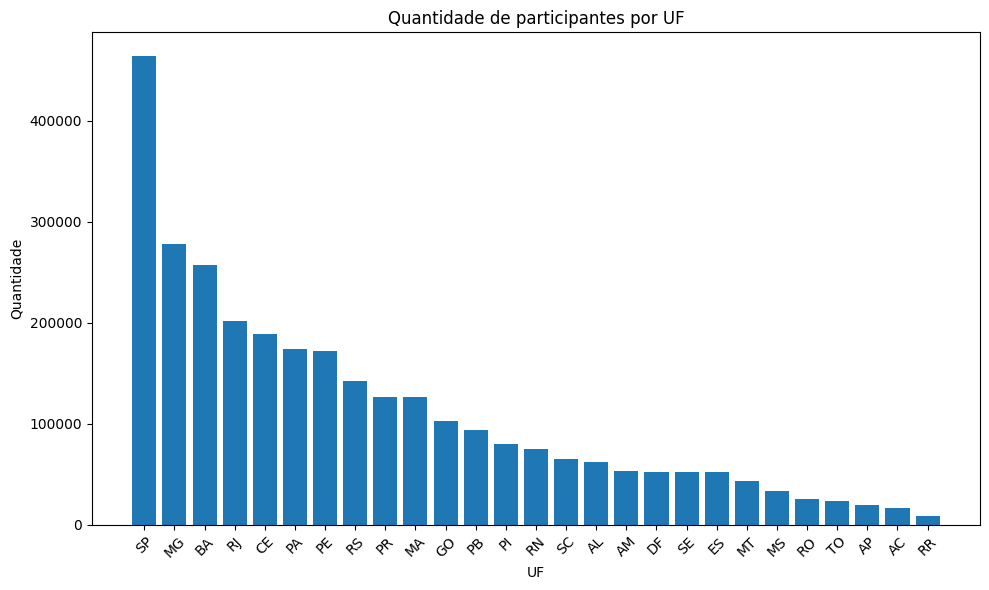

In [14]:
plt.figure(figsize=(10, 6))
plt.bar(uf, quantidades)
plt.title("Quantidade de participantes por UF")
plt.xlabel("UF")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conclusão

Este notebook mostrou:

- como filtrar candidatos com base em critérios mínimos de desempenho
- como calcular médias por unidade federativa
- como criar uma média simples geral
- como gerar um ranking dos estados com base no desempenho médio
- como visualizar a quantidade de participantes por UF com um gráfico de barras